In [12]:
from featuregraph.datasets import arc_agi
import featuregraph as fg
import matplotlib.pyplot as plt

df = arc_agi("00576224", split="training")

In [13]:
pair_type = 'train'
pair_index = 1

def reconstruct_grid(df, pair_type, pair_index, grid_role):
    mask = (df['pair_type'] == pair_type) & (df['pair_index'] == pair_index) & (df['grid_role'] == grid_role)
    cells = df[mask]

    return cells.pivot(
        index="row",
        columns="column",
        values="color",
    ).to_numpy()


input = reconstruct_grid(df, pair_type, pair_index, 'input')
output = reconstruct_grid(df, pair_type, pair_index, 'output')

cells = fg.behaviors.spatial.partition_blocks(input, output)
blocks = fg.behaviors.spatial.compare_blocks(cells)
layout, operators = fg.behaviors.spatial.build_instruction_layout(blocks)
manual_output = fg.behaviors.spatial.block_compose(layout, input, operators)
match = fg.behaviors.spatial.exact_match(manual_output, output)

print('Exact match:', match)

Exact match: True


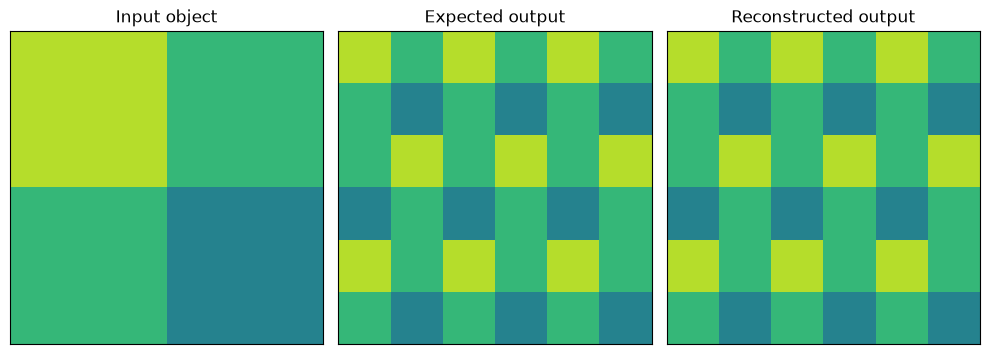

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(10, 4))

axes[0].imshow(input, vmin=0, vmax=9)
axes[0].set_title("Input object")

axes[1].imshow(output, vmin=0, vmax=9)
axes[1].set_title("Expected output")

axes[2].imshow(manual_output, vmin=0, vmax=9)
axes[2].set_title("Reconstructed output")

for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()